### 0. Setup & Imports

In [22]:
import os
print(os.getcwd())

/Users/lisatabatchnikov


In [3]:
import pandas as pd

df = pd.read_csv("cvd_dataset.csv")

### 1. Data Exploration & Class Distribution

In [4]:
print(df.head())

  Sex   Age  Weight (kg)  Height (m)   BMI  Abdominal Circumference (cm)  \
0   F  32.0         69.1        1.71  23.6                          86.2   
1   F  55.0        118.7        1.69  41.6                          82.5   
2   M   NaN          NaN        1.83  26.9                         106.7   
3   M  44.0        108.3        1.80  33.4                          96.6   
4   F  32.0         99.5        1.86  28.8                         102.7   

  Blood Pressure (mmHg)  Total Cholesterol (mg/dL)  HDL (mg/dL)  \
0                125/79                      248.0         78.0   
1                139/70                      162.0         50.0   
2                104/77                      103.0         73.0   
3                140/83                      134.0         46.0   
4                144/83                      146.0         64.0   

   Fasting Blood Sugar (mg/dL)  ... Physical Activity Level  \
0                        111.0  ...                     Low   
1             

In [5]:
print(df.shape)

(1529, 22)


In [6]:
print(df.columns)

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

In [8]:
df.isna().sum()

Sex                              0
Age                             78
Weight (kg)                     81
Height (m)                      67
BMI                             64
Abdominal Circumference (cm)    67
Blood Pressure (mmHg)            0
Total Cholesterol (mg/dL)       73
HDL (mg/dL)                     80
Fasting Blood Sugar (mg/dL)     67
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Height (cm)                     74
Waist-to-Height Ratio           79
Systolic BP                     71
Diastolic BP                    82
Blood Pressure Category          0
Estimated LDL (mg/dL)           69
CVD Risk Score                  70
CVD Risk Level                   0
dtype: int64

In [9]:
counts = df["CVD Risk Level"].value_counts()
percentages = df["CVD Risk Level"].value_counts(normalize=True).mul(100).round(1)

print("Class Distribution:")
for cls in counts.index:
    print(f"  {cls}: {counts[cls]} ({percentages[cls]}%)")

Class Distribution:
  HIGH: 728 (47.6%)
  INTERMEDIARY: 581 (38.0%)
  LOW: 220 (14.4%)


In [10]:
print(df.describe())

               Age  Weight (kg)   Height (m)          BMI  \
count  1451.000000  1448.000000  1462.000000  1465.000000   
mean     47.025500    85.917427     1.754111    28.465997   
std      12.421063    21.012580     0.113090     7.038685   
min      25.000000    50.100000     1.502000    15.000000   
25%      37.000000    67.050000     1.660000    22.629000   
50%      46.000000    86.614500     1.755000    28.159000   
75%      55.000000   105.000000     1.845500    34.000000   
max      79.000000   120.000000     2.000000    46.200000   

       Abdominal Circumference (cm)  Total Cholesterol (mg/dL)  HDL (mg/dL)  \
count                   1462.000000                1456.000000  1449.000000   
mean                      91.773214                 198.539148    56.197378   
std                       12.823573                  57.794099    16.066754   
min                       70.000000                 100.000000    30.000000   
25%                       80.500000                 150

### 2. Data Preperation 

In [11]:
target = "CVD Risk Level"

X = df.drop(columns=[target])
y = df[target]

In [12]:
X = X.drop(columns=["Blood Pressure (mmHg)"]) 
X = X.drop(columns=["CVD Risk Score"]) 
X = X.drop(columns=["BMI"]) 
X = X.drop(columns=["Height (cm)"]) 

In [13]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
print(numeric_features)
categorical_features = X.select_dtypes(include=["object"]).columns
print(categorical_features)

Index(['Age', 'Weight (kg)', 'Height (m)', 'Abdominal Circumference (cm)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Waist-to-Height Ratio', 'Systolic BP',
       'Diastolic BP', 'Estimated LDL (mg/dL)'],
      dtype='object')
Index(['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level',
       'Family History of CVD', 'Blood Pressure Category'],
      dtype='object')


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#numerical pipeline: handeling missing values & scaling 
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#categorical pipeline: handeling missing values - OneHotEncoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#column transformer 
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### 3. Model Comparison (Training & Evaluation)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from scipy import sparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Convert sparse output from OneHotEncoder to dense if needed
def to_dense(X):
    if sparse.issparse(X):
        return X.toarray()
    return X


models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "SVC": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_metrics = []
all_model_predictions = {}

for model_name, classifier in models.items():

    print(f"\nTraining model: {model_name}")

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("to_dense", FunctionTransformer(to_dense, accept_sparse=True)),
        ("classifier", classifier)
    ])

    fold_metrics = []
    fold_predictions = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)

        acc = accuracy_score(y_val, y_pred)
        bal_acc = balanced_accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average="macro")

        auc = roc_auc_score(
            y_val,
            y_proba,
            multi_class="ovr",
            average="macro",
            labels=model.classes_
        )

        fold_metrics.append({
            "model": model_name,
            "fold": fold,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "f1_macro": f1,
            "auc_macro": auc
        })

        fold_df = pd.DataFrame({
            "true": y_val.values,
            "pred": y_pred
        })

        proba_df = pd.DataFrame(
            y_proba,
            columns=[f"proba_{c}" for c in model.classes_]
        )

        fold_df = pd.concat(
            [fold_df.reset_index(drop=True), proba_df],
            axis=1
        )

        fold_df["model"] = model_name
        fold_df["fold"] = fold
        fold_df["max_proba"] = proba_df.max(axis=1)
        fold_df["correct"] = fold_df["true"] == fold_df["pred"]

        fold_predictions.append(fold_df)

    model_metrics_df = pd.DataFrame(fold_metrics)
    model_predictions_df = pd.concat(fold_predictions, ignore_index=True)

    all_metrics.append(model_metrics_df)
    all_model_predictions[model_name] = model_predictions_df


metrics_all_df = pd.concat(all_metrics, ignore_index=True)

comparison_df = (
    metrics_all_df
    .groupby("model")[["accuracy", "balanced_accuracy", "f1_macro", "auc_macro"]]
    .mean()
    .sort_values("f1_macro", ascending=False)
    .round(3)
)

print("\nModel Comparison:")
print(comparison_df)


Training model: Logistic Regression

Training model: Decision Tree

Training model: Random Forest

Training model: Extra Trees

Training model: Gradient Boosting

Training model: Hist Gradient Boosting

Training model: AdaBoost

Training model: KNN

Training model: Gaussian Naive Bayes

Training model: SVC

Model Comparison:
                        accuracy  balanced_accuracy  f1_macro  auc_macro
model                                                                   
SVC                        0.633              0.603     0.586      0.800
Gaussian Naive Bayes       0.625              0.549     0.547      0.734
Hist Gradient Boosting     0.653              0.537     0.533      0.779
Logistic Regression        0.587              0.541     0.531      0.727
Gradient Boosting          0.664              0.534     0.524      0.775
AdaBoost                   0.664              0.522     0.495      0.742
Random Forest              0.647              0.509     0.489      0.807
Extra Trees    

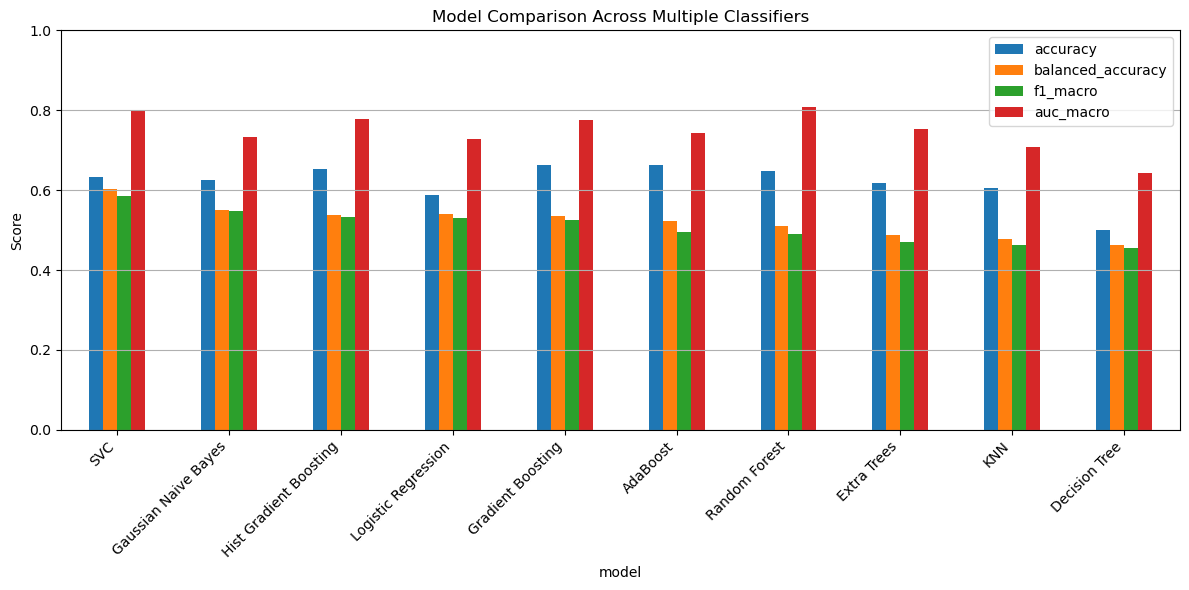

In [17]:
comparison_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Comparison Across Multiple Classifiers")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
predictions_df = all_model_predictions["SVC"].copy()
print("Final model selected: SVC")

Final model selected: SVC


In [19]:
from sklearn.metrics import roc_curve, auc as sklearn_auc
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(predictions_df_model, model_name):
    last_fold = predictions_df_model[
        predictions_df_model["fold"] == predictions_df_model["fold"].max()
    ].copy()
    
    proba_cols = [col for col in predictions_df_model.columns if col.startswith("proba_")]
    classes = [col.replace("proba_", "") for col in proba_cols]
    
    y_true_bin = label_binarize(last_fold["true"], classes=classes)
    y_proba = last_fold[proba_cols].values
    
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#B2182B", "#2166AC", "#4DAC26"]
    
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        auc_score = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {auc_score:.3f})")
    
    ax.plot([0, 1], [0, 1], "k--", label="Baseline (AUC = 0.5)")
    ax.set_title(f"ROC Curve per Class — {model_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curve_svc.png", dpi=150)
    plt.show()

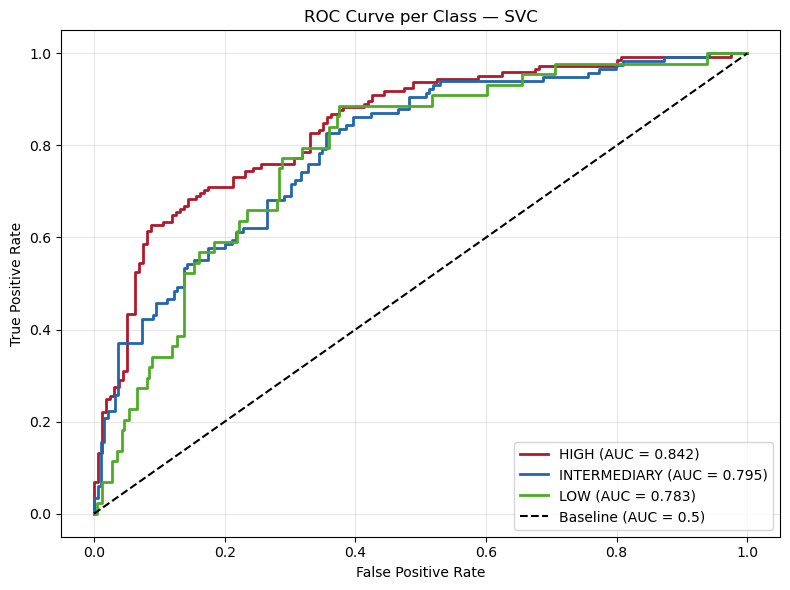

In [20]:
plot_multiclass_roc(all_model_predictions["SVC"], "SVC")

### 4. MCC Score Calculation & Validity

In [ ]:
predictions_df = all_model_predictions["SVC"].copy()

def calculate_mcc(row, proba_columns, n_classes):
    probas = row[proba_columns].values
    p_yhat = probas.max()
    p_beta = sorted(probas)[-2]
    
    if p_yhat == 0:
        return float('-inf')
    
    mcc = 1 - (p_beta / (p_yhat ** 2)) / n_classes
    return mcc

proba_columns = [col for col in predictions_df.columns if col.startswith("proba_")]
n_classes = 3

predictions_df["mcc"] = predictions_df.apply(
    lambda row: calculate_mcc(row, proba_columns, n_classes), axis=1
)

print(f"MCC range: {predictions_df['mcc'].min():.3f} to {predictions_df['mcc'].max():.3f}")
print(f"Mean MCC: {predictions_df['mcc'].mean():.3f}")

In [ ]:
predictions_df["mcc_quartile"] = pd.qcut(
    predictions_df["mcc"],
    q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)

quartile_analysis = predictions_df.groupby("mcc_quartile", observed=True).agg(
    n_predictions=("mcc", "count"),
    accuracy=("correct", "mean"),
    mean_mcc=("mcc", "mean")
).round(3)

print("Accuracy per MCC Quartile:")
print(quartile_analysis)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

classes = ["HIGH", "INTERMEDIARY", "LOW"]

for i, cls in enumerate(classes):
    
    class_df = predictions_df[predictions_df["true"] == cls]
    
    class_df[class_df["correct"] == True]["mcc"].hist(
        bins=20, alpha=0.6, color="green", label="Correct", ax=axes[i]
    )
    class_df[class_df["correct"] == False]["mcc"].hist(
        bins=20, alpha=0.6, color="red", label="Incorrect", ax=axes[i]
    )
    
    axes[i].set_title("MCC: Correct vs Incorrect\n(True class = " + cls + ")")
    axes[i].set_xlabel("MCC Score")
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

classes = ["HIGH", "INTERMEDIARY", "LOW"]

for i, cls in enumerate(classes):
    
    class_df = predictions_df[predictions_df["pred"] == cls]
    
    class_df[class_df["correct"] == True]["mcc"].hist(
        bins=20, alpha=0.6, color="green", label="Correct", ax=axes[i]
    )
    class_df[class_df["correct"] == False]["mcc"].hist(
        bins=20, alpha=0.6, color="red", label="Incorrect", ax=axes[i]
    )
    
    axes[i].set_title(f"MCC: Correct vs Incorrect\n(Predicted class = {cls})")
    axes[i].set_xlabel("MCC Score")
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
quartile_class_dist = predictions_df.groupby(
    ["mcc_quartile", "true"], observed=True
).size().unstack(fill_value=0)

quartile_class_dist_pct = quartile_class_dist.div(
    quartile_class_dist.sum(axis=1), axis=0
).mul(100).round(1)

print("True class distribution per MCC quartile (%):")
print(quartile_class_dist_pct)

### 5. Threshold Analysis & Zone Classification

In [ ]:
def apply_mcc_strategy(df, mcc_threshold, target_class):
    df2 = df.copy()
    
    if mcc_threshold == 0.0:
        return df2
    
    below_mask = df2["mcc"] < mcc_threshold
    proba_columns = [c for c in df2.columns if c.startswith("proba_")]
    
    def get_zone(row):
        p = {col.replace("proba_", ""): row[col] for col in proba_columns}
        sorted_cls = sorted(p, key=p.get, reverse=True)
        top1, top2, top3 = sorted_cls
        if p[top2] - p[top3] < 0.05:
            return "zone0"
        pair = tuple(sorted([top1, top2]))
        if pair == ("INTERMEDIARY", "LOW"):
            return "zone1"
        return "zone2"
    
    df2.loc[below_mask, "zone"] = df2[below_mask].apply(get_zone, axis=1)
    
    upward_mask = below_mask & df2["zone"].isin(["zone2"])
    df2.loc[upward_mask, "pred"] = "HIGH"
    for col in proba_columns:
        cls = col.replace("proba_", "")
        df2.loc[upward_mask, col] = 1.0 if cls == "HIGH" else 0.0
    
    return df2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mcc_thresholds = [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
fn_values = []
fp_values = []
zone0_values = []

N_total = len(predictions_df)
N_high = (predictions_df["true"] == "HIGH").sum()
N_non_high = (predictions_df["true"] != "HIGH").sum()

for t in mcc_thresholds:
    df_strat = apply_mcc_strategy(predictions_df, t, target_class="HIGH")
    fn = ((df_strat["true"] == "HIGH") & (df_strat["pred"] != "HIGH")).sum()
    fp = ((df_strat["pred"] == "HIGH") & (df_strat["true"] != "HIGH")).sum()
    zone0 = (df_strat.get("zone", pd.Series()) == "zone0").sum()
    
    fn_values.append(fn / N_high * 100)
    fp_values.append(fp / N_non_high * 100)
    zone0_values.append(zone0 / N_total * 100)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(mcc_thresholds, fn_values, marker="o", color="#B2182B",
        linewidth=2.5, label=f"False Negatives (% of true HIGH, n={N_high})")
ax.plot(mcc_thresholds, fp_values, marker="s", color="#2166AC",
        linewidth=2.5, label=f"False Positives (% of non-HIGH, n={N_non_high})")
ax.plot(mcc_thresholds, zone0_values, marker="^", color="#4DAC26",
        linewidth=2.0, linestyle="--", label=f"Clinical Review Group (% of all, n={N_total})")

idx_05 = mcc_thresholds.index(0.5)
ax.annotate(f"{fn_values[idx_05]:.1f}%",
            xy=(0.5, fn_values[idx_05]),
            xytext=(0.52, fn_values[idx_05] - 3),
            fontsize=8, color="#B2182B")
ax.annotate(f"{fp_values[idx_05]:.1f}%",
            xy=(0.5, fp_values[idx_05]),
            xytext=(0.42, fp_values[idx_05] + 1),
            fontsize=8, color="#2166AC")
ax.annotate(f"{zone0_values[idx_05]:.1f}%",
            xy=(0.5, zone0_values[idx_05]),
            xytext=(0.52, zone0_values[idx_05] + 1),
            fontsize=8, color="#4DAC26")

ax.axvline(x=0.5, color="gray", linewidth=1.5, linestyle="--")
ax.text(0.51, ax.get_ylim()[1] * 0.80, "τ = 0.5\n(selected)", fontsize=9, color="gray")

ax.set_xlabel("MCC Threshold (τ)")
ax.set_ylabel("Percentage of patients (%)")
ax.set_title("Clinical Trade-off by MCC Threshold\nFalse Negatives vs. False Positives")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fn_fp_tradeoff.png", dpi=150)
plt.show()

In [ ]:
mcc_thresholds_analysis = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in mcc_thresholds_analysis:
    df_strat = apply_mcc_strategy(predictions_df, t, target_class="HIGH")
    below = df_strat[df_strat["mcc"] < t]
    above = df_strat[df_strat["mcc"] >= t]
    
    fn = ((df_strat["true"] == "HIGH") & (df_strat["pred"] != "HIGH")).sum()
    
    print(f"\nThreshold = {t}")
    print(f"  Patients below threshold: {len(below)} ({len(below)/N_total*100:.1f}%)")
    print(f"  Patients above threshold: {len(above)} ({len(above)/N_total*100:.1f}%)")
    if len(below) > 0:
        zone_counts = below["zone"].value_counts()
        print(f"  Zone 0 (all uncertain): {zone_counts.get('zone0', 0)}")
        print(f"  Zone 1 (Low ↔ Inter)  : {zone_counts.get('zone1', 0)}")
        print(f"  Zone 2 (Inter ↔ High) : {zone_counts.get('zone2', 0)}")
    print(f"  Missed High-Risk (FN): {fn}")

### 6. Zone-Specific Analysis

In [ ]:
predictions_df_with_zones = apply_mcc_strategy(predictions_df, mcc_threshold=0.5, target_class="HIGH")

below = predictions_df_with_zones[predictions_df_with_zones["mcc"] < 0.5]
zone_counts = below["zone"].value_counts()

print(f"Patients below threshold (τ=0.5): {len(below)} ({len(below)/len(predictions_df)*100:.1f}%)")
print(f"  Zone 0 (Clinical Review Group): {zone_counts.get('zone0', 0)}")
print(f"  Zone 1 (No-Action Group):       {zone_counts.get('zone1', 0)}")
print(f"  Zone 2 (Upclassification Group):{zone_counts.get('zone2', 0)}")

In [ ]:
# Zone 0
zone0 = below[below["zone"] == "zone0"]
print("=== Clinical Review Group (Zone 0) ===")
print(zone0["true"].value_counts())
print(zone0["true"].value_counts(normalize=True).mul(100).round(1))

# Zone 1
zone1 = below[below["zone"] == "zone1"]
print("\n=== No-Action Group (Zone 1) ===")
print(zone1["true"].value_counts())
print(zone1["true"].value_counts(normalize=True).mul(100).round(1))

# Zone 2
zone2 = below[below["zone"] == "zone2"]
print("\n=== Upclassification Group (Zone 2) ===")
print(zone2["true"].value_counts())
print(zone2["true"].value_counts(normalize=True).mul(100).round(1))

### 7. Cost-Effectiveness Analysis

In [ ]:
df_standard = apply_mcc_strategy(predictions_df, 0.0, target_class="HIGH")
df_uncertainty = apply_mcc_strategy(predictions_df, 0.5, target_class="HIGH")

fn_standard = ((df_standard["true"] == "HIGH") & (df_standard["pred"] != "HIGH")).sum()
fp_standard = ((df_standard["pred"] == "HIGH") & (df_standard["true"] != "HIGH")).sum()

fn_uncertainty = ((df_uncertainty["true"] == "HIGH") & (df_uncertainty["pred"] != "HIGH")).sum()
fp_uncertainty = ((df_uncertainty["pred"] == "HIGH") & (df_uncertainty["true"] != "HIGH")).sum()

zone0_referrals = (df_uncertainty["zone"] == "zone0").sum()

print(f"Standard Screening   — FN: {fn_standard}, FP: {fp_standard}")
print(f"Uncertainty-Informed — FN: {fn_uncertainty}, FP: {fp_uncertainty}")
print(f"CVD events prevented: {fn_standard - fn_uncertainty}")
print(f"Zone 0 referrals:     {zone0_referrals}")

In [ ]:
# Bangladesh cost parameters
bd_event_cost      = 480    # USD per CVD event (Mohanan et al. 2019)
bd_prevention_cost = 55     # USD per patient/year (Husain et al. 2022)
bd_screening_cost  = 1      # USD per patient (Hasan et al. 2025)
bd_gp_cost         = 3.40   # USD per GP consultation (Hasan et al. 2025)

# Europe cost parameters
eu_event_cost      = 7800   # EUR per CVD event (Schmid et al. 2015)
eu_prevention_cost = 595    # EUR per patient/year (Jülicher et al. 2024)
eu_screening_cost  = 25     # EUR per patient (Kypridemos et al. 2018)
eu_gp_cost         = 44     # EUR per GP consultation (Jülicher et al. 2024)

N_total = len(predictions_df)

In [ ]:
def calculate_costs(fn_std, fn_unc, fp_unc, zone0_n, n_total,
                    event_cost, prevention_cost, screening_cost, gp_cost, currency):

    events_prevented   = fn_std - fn_unc

    # Standard screening
    cvd_cost_std       = fn_std * event_cost
    screening_cost_std = n_total * screening_cost
    total_std          = cvd_cost_std + screening_cost_std

    # Uncertainty-informed screening
    cvd_cost_unc       = fn_unc * event_cost
    prevention_total   = fp_unc * prevention_cost
    screening_cost_unc = n_total * screening_cost
    gp_cost_total      = zone0_n * gp_cost
    total_unc          = cvd_cost_unc + prevention_total + screening_cost_unc + gp_cost_total

    savings            = total_std - total_unc
    savings_pct        = round((savings / total_std) * 100, 1)

    return {
        "currency":                   currency,
        "False Negatives":            [fn_std, fn_unc],
        "CVD events prevented":       events_prevented,
        "CVD event costs":            [cvd_cost_std, cvd_cost_unc],
        "Preventive treatment costs": [0, prevention_total],
        "GP consultation costs":      [0, round(gp_cost_total, 2)],
        "Screening costs":            [screening_cost_std, screening_cost_unc],
        "Total costs":                [round(total_std, 2), round(total_unc, 2)],
        "Cost savings":               round(savings, 2),
        "Cost savings (%)":           savings_pct,
    }

In [ ]:
bd = calculate_costs(
    fn_standard, fn_uncertainty, fp_uncertainty, zone0_referrals, N_total,
    bd_event_cost, bd_prevention_cost, bd_screening_cost, bd_gp_cost, "USD"
)

eu = calculate_costs(
    fn_standard, fn_uncertainty, fp_uncertainty, zone0_referrals, N_total,
    eu_event_cost, eu_prevention_cost, eu_screening_cost, eu_gp_cost, "EUR"
)

metrics = [
    "False Negatives",
    "CVD events prevented",
    "CVD event costs",
    "Preventive treatment costs",
    "GP consultation costs",
    "Screening costs",
    "Total costs",
    "Cost savings",
    "Cost savings (%)",
]

rows = []
for m in metrics:
    bd_val = bd[m]
    eu_val = eu[m]

    if m == "Cost savings (%)":
        rows.append({
            "Metric":                   m,
            "Bangladesh — Standard":    "—",
            "Bangladesh — Uncertainty": f"{bd_val}%",
            "Europe — Standard":        "—",
            "Europe — Uncertainty":     f"{eu_val}%",
        })
    elif m in ["False Negatives", "CVD events prevented"]:
        if isinstance(bd_val, list):
            rows.append({
                "Metric":                   m,
                "Bangladesh — Standard":    str(bd_val[0]),
                "Bangladesh — Uncertainty": str(bd_val[1]),
                "Europe — Standard":        str(eu_val[0]),
                "Europe — Uncertainty":     str(eu_val[1]),
            })
        else:
            rows.append({
                "Metric":                   m,
                "Bangladesh — Standard":    "—",
                "Bangladesh — Uncertainty": str(bd_val),
                "Europe — Standard":        "—",
                "Europe — Uncertainty":     str(eu_val),
            })
    elif isinstance(bd_val, list):
        rows.append({
            "Metric":                   m,
            "Bangladesh — Standard":    f"{bd['currency']} {bd_val[0]:,}",
            "Bangladesh — Uncertainty": f"{bd['currency']} {bd_val[1]:,}",
            "Europe — Standard":        f"{eu['currency']} {eu_val[0]:,}",
            "Europe — Uncertainty":     f"{eu['currency']} {eu_val[1]:,}",
        })
    else:
        rows.append({
            "Metric":                   m,
            "Bangladesh — Standard":    "—",
            "Bangladesh — Uncertainty": f"{bd['currency']} {bd_val:,}",
            "Europe — Standard":        "—",
            "Europe — Uncertainty":     f"{eu['currency']} {eu_val:,}",
        })

results_df = pd.DataFrame(rows).set_index("Metric")
print(results_df.to_string())

In [ ]:
# At τ=0.5
df_05 = apply_mcc_strategy(predictions_df, 0.5, target_class="HIGH")
treated_05 = (df_05["pred"] == "HIGH").sum()
tp_05 = ((df_05["pred"] == "HIGH") & (df_05["true"] == "HIGH")).sum()
fp_05 = ((df_05["pred"] == "HIGH") & (df_05["true"] != "HIGH")).sum()

# At τ=0.6
df_06 = apply_mcc_strategy(predictions_df, 0.6, target_class="HIGH")
treated_06 = (df_06["pred"] == "HIGH").sum()
tp_06 = ((df_06["pred"] == "HIGH") & (df_06["true"] == "HIGH")).sum()
fp_06 = ((df_06["pred"] == "HIGH") & (df_06["true"] != "HIGH")).sum()

print(f"τ=0.5: treated={treated_05}, TP={tp_05}, FP={fp_05}, TP/FP ratio={tp_05/fp_05:.2f}")
print(f"τ=0.6: treated={treated_06}, TP={tp_06}, FP={fp_06}, TP/FP ratio={tp_06/fp_06:.2f}")
print(f"Additional treated at τ=0.6: {treated_06-treated_05}")
print(f"Additional TP at τ=0.6: {tp_06-tp_05}")
print(f"Additional FP at τ=0.6: {fp_06-fp_05}")